In [1]:
import openai
from svg_vision_reflection import generate_svg
generate_svg?

Signature:
generate_svg(
    prompt: str,
    num_reflections: int = 2,
    report_history: bool = False,
    model: str = 'gpt-4o',
    openai_client: openai.OpenAI = None,
)
Docstring:
Generate an SVG image from a text prompt using an LLM and iterative visual reflection.

Parameters
----------
prompt : str
    A natural-language description of what the SVG should show.
num_reflections : int, optional
    Number of vision-based refinement iterations (default: 2).
report_history : bool, optional
    When *True* the function returns a tuple ``(svg, history)`` where
    *history* is a list of ``(svg_str, png_bytes)`` tuples captured after
    each reflection step.
model : str, optional
    OpenAI model to use (default: ``"gpt-4o"``).
openai_client : openai.OpenAI, optional
    A pre-configured OpenAI client instance.  A default client is created
    from environment variables when *None*.

Returns
-------
str or tuple
    The final SVG content as a string.  When *report_history* is *True

In [2]:
#client = openai.OpenAI(base_url = "http://localhost:11434/v1", api_key = "none")

In [3]:
#svg, history = generate_svg("a penguin riding a bike", openai_client=client, model="gemma3:4b", report_history=True)

In [4]:
svg, history = generate_svg("a penguin riding a bike shown from the side", num_reflections=20, report_history=True)

In [5]:
svg

'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 200 200" width="200px" height="200px">\n    <!-- Front Bike Wheel -->\n    <circle cx="50" cy="150" r="30" stroke="black" stroke-width="3" fill="gray"/>\n    <!-- Back Bike Wheel -->\n    <circle cx="130" cy="150" r="30" stroke="black" stroke-width="3" fill="gray"/>\n    \n    <!-- Bike frame for side view -->\n    <line x1="50" y1="150" x2="90" y2="120" stroke="black" stroke-width="3"/>\n    <line x1="90" y1="120" x2="130" y2="150" stroke="black" stroke-width="3"/>\n    <line x1="90" y1="120" x2="90" y2="100" stroke="black" stroke-width="3"/>\n    \n    <!-- Bike handlebars for side view -->\n    <line x1="90" y1="100" x2="110" y2="90" stroke="black" stroke-width="3"/>\n    <line x1="110" y1="90" x2="115" y2="85" stroke="black" stroke-width="3"/>\n    \n    <!-- Bike seat -->\n    <rect x="86" y="108" width="8" height="3" fill="black"/>\n    \n    <!-- Penguin body for side view -->\n    <ellipse cx="95" cy="80" rx="15" ry="24" fil

In [6]:
len(history)

20


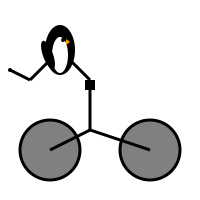

In [7]:
import numpy as np
import stackview
from PIL import Image
from io import BytesIO

def png_to_array(png_data):
    """
    Converts a PNG image byte-stream to a NumPy array.

    Args:
        png_data (bytes): PNG image data as a byte stream.

    Returns:
        np.ndarray: A NumPy array representing the image, or None if an error occurs.
    """
    # Convert the byte array to a BytesIO stream before opening
    img = Image.open(BytesIO(png_data))
    return np.array(img)

# Assuming `history[0][1]` contains PNG byte data
image_array = []
for h in history:
    image_array.append(png_to_array(h[1]))
    
stackview.animate(image_array, filename="docs/images/demo.gif")